In [61]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import requests
from sklearn.metrics import confusion_matrix, classification_report

import pandas as pd
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
SUBCATEGORY_TO_LABEL = {
    "Tops":       0,
    "Bottomwear": 1,
    "Shoes":      2,
    "Dress":      3,
    "Outerwear":  4,
}

# Reverse mapping — useful for interpreting predictions later
LABEL_TO_SUBCATEGORY = {v: k for k, v in SUBCATEGORY_TO_LABEL.items()}

In [44]:
def download_image(url):
    try:
        response = requests.get(url, timeout=2)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Failed to download {url}: {e}")
        return None


class WardrobeDataset(Dataset):

    def __init__(self, df, local_image_dir=None, image_size=224):
        """
        Args:
            df              : dataframe with columns 'id', 'link', 'subCategory'
            local_image_dir : if images are already saved locally, provide path here
                              to load from disk instead of downloading every time
            image_size      : input size for ResNet (224)
        """
        self.df              = df.reset_index(drop=True)
        self.local_image_dir = local_image_dir

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],  # ImageNet mean
                std=[0.229, 0.224, 0.225]    # ImageNet std
            )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        image_id     = row["id"]
        url          = row["link"]
        sub_category = row["subCategory"]
        label        = SUBCATEGORY_TO_LABEL.get(sub_category, -1)

        # Load from disk if available, otherwise download from URL
        if self.local_image_dir:
            local_path = os.path.join(self.local_image_dir, f"{image_id}.jpg")
            img = Image.open(local_path).convert("RGB") if os.path.exists(local_path) else download_image(url)
        else:
            img = download_image(url)

        # Return blank tensor if image failed — won't crash the training loop
        if img is None:
            return torch.zeros(3, 224, 224), label

        # No crop — images are already 80-90% the target item
        img = self.transform(img)
        return img, label

### Skip images that didn't download(only 1 bad image)

In [54]:
from pathlib import Path

balanced_df = pd.read_csv("../data/balanced_df.csv")

img_dir = Path("../data/balanced_images")
balanced_df = balanced_df[
    balanced_df["id"].apply(lambda x: (img_dir / f"{x}.jpg").exists())
].reset_index(drop=True)

balanced_df


,filename,link,file_id,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,7643.jpg,http://assets.myntassets.com/v1/images/style/p...,7643,7643,Men,Apparel,Tops,Tshirts,Red,Fall,2011.0,Sports,Puma Men's Ducati Logo Red T-shirt
1,58734.jpg,http://assets.myntassets.com/v1/image/style/pr...,58734,58734,Men,Apparel,Tops,Tshirts,Red,Fall,2012.0,Sports,PUMA Men Red Printed T-shirt
2,14643.jpg,http://assets.myntassets.com/v1/images/style/p...,14643,14643,Men,Apparel,Tops,Shirts,White,Fall,2011.0,Casual,Probase Men Classic White White Shirts
3,38340.jpg,http://assets.myntassets.com/v1/images/style/p...,38340,38340,Girls,Apparel,Tops,Tops,Off White,Summer,2012.0,Casual,Mr. Men Little Miss Girls Off White Top
4,34028.jpg,http://assets.myntassets.com/v1/images/style/p...,34028,34028,Boys,Apparel,Tops,Shirts,Black,Summer,2012.0,Casual,Gini and Jony Boys Check White & Black Shirt
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,11368.jpg,http://assets.myntassets.com/v1/images/style/p...,11368,11368,Women,Apparel,Outerwear,Jackets,Black,Fall,2011.0,Casual,United Colors Of Benetton Women Light Winter B...
1390,22313.jpg,http://assets.myntassets.com/v1/images/style/p...,22313,22313,Men,Apparel,Outerwear,Jackets,Black,Summer,2015.0,Casual,Wildcraft Men Black Fleece Jacket
1391,10017.jpg,http://assets.myntassets.com/v1/images/style/p...,10017,10017,Women,Apparel,Outerwear,Jackets,Blue,Fall,2011.0,Sports,Nike Women As The Windru Blue Jackets
1392,22314.jpg,http://assets.myntassets.com/v1/images/style/p...,22314,22314,Women,Apparel,Outerwear,Jackets,Black,Fall,2011.0,Casual,Wildcraft Women Solid Black Jacket


In [46]:
# Shuffle and split combined_df 80/20



train_df, val_df = train_test_split(balanced_df, test_size=.2, random_state=42, stratify=balanced_df['subCategory'])

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

# Create datasets
# If you have images saved locally, pass local_image_dir="data/processed/images/"
# Otherwise leave it out and it will download from URLs on the fly
train_dataset = WardrobeDataset(train_df, local_image_dir="../data/balanced_images")
val_dataset   = WardrobeDataset(val_df, local_image_dir="../data/balanced_images")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

Training samples:   1116
Validation samples: 279


In [47]:
NUM_CLASSES = 5  # Tops, Bottomwear, Shoes, Dress, Outerwear

model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all layers — only train the final classifier head
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer with one that outputs 5 classes
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Move to GPU if available
device = 'mps'
model  = model.to(device)

print(f"Using device: {device}")

Using device: mps


In [48]:
criterion = nn.CrossEntropyLoss()

# Only optimize the final layer since everything else is frozen
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

### Too ineffecient to download images while training, 2 minutes per batch, 14 mins per epoch, we gotta download it before hand

In [52]:
NUM_EPOCHS = 20

for epoch in range(NUM_EPOCHS):

    # ── Training ──────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

   
    for batch_idx, (images, labels) in enumerate(train_loader):
       
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += labels.size(0)

    train_acc = train_correct / train_total

    # ── Validation ────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.4f}")

Failed to download undefined: Invalid URL 'undefined': No scheme supplied. Perhaps you meant https://undefined?
Epoch 1/20 | Train Loss: 0.2431 | Train Acc: 0.9194 | Val Loss: 0.2434 | Val Acc: 0.9247
Failed to download undefined: Invalid URL 'undefined': No scheme supplied. Perhaps you meant https://undefined?
Epoch 2/20 | Train Loss: 0.1803 | Train Acc: 0.9346 | Val Loss: 0.2102 | Val Acc: 0.9355
Failed to download undefined: Invalid URL 'undefined': No scheme supplied. Perhaps you meant https://undefined?
Epoch 3/20 | Train Loss: 0.2162 | Train Acc: 0.9238 | Val Loss: 0.2225 | Val Acc: 0.9211
Failed to download undefined: Invalid URL 'undefined': No scheme supplied. Perhaps you meant https://undefined?
Epoch 4/20 | Train Loss: 0.1932 | Train Acc: 0.9274 | Val Loss: 0.2667 | Val Acc: 0.9032
Failed to download undefined: Invalid URL 'undefined': No scheme supplied. Perhaps you meant https://undefined?
Epoch 5/20 | Train Loss: 0.1566 | Train Acc: 0.9534 | Val Loss: 0.2039 | Val Acc: 0.

### Future things to add, learning rate scheduler, weight decay, data augmentation, unfreeze lower layers for fine tuning(layer 4)

In [53]:
os.makedirs("../models", exist_ok=True)
torch.save(model.state_dict(), "../models/resnet50_stylesync.pt")
print("Model saved to models/resnet50_stylesync.pt")

Model saved to models/resnet50_stylesync.pt


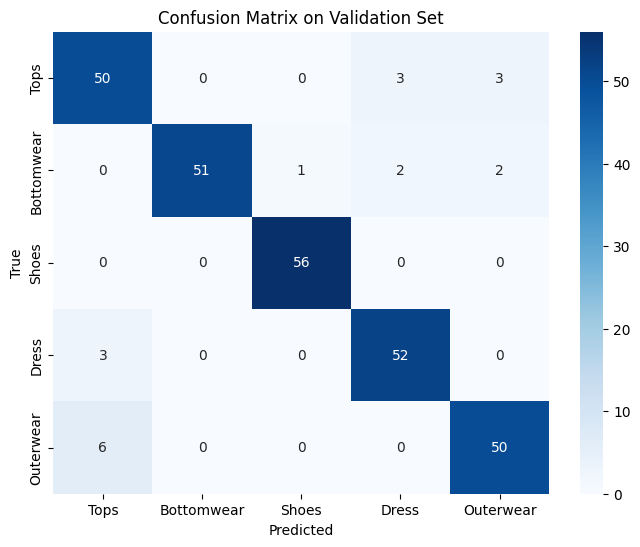

              precision    recall  f1-score   support

        Tops       0.85      0.89      0.87        56
  Bottomwear       1.00      0.91      0.95        56
       Shoes       0.98      1.00      0.99        56
       Dress       0.91      0.95      0.93        55
   Outerwear       0.91      0.89      0.90        56

    accuracy                           0.93       279
   macro avg       0.93      0.93      0.93       279
weighted avg       0.93      0.93      0.93       279



In [62]:
model.load_state_dict(torch.load("../models/resnet50_stylesync.pt", map_location=device))
model = model.to(device)
model.eval()
all_preds = []
all_labels = []
class_names = ["Tops", "Bottomwear", "Shoes", "Dress", "Outerwear"]

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        output = model(images)
        preds = output.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix on Validation Set")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))